In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('train37.csv' , usecols=['GarageQual' , 'FireplaceQu' , 'SalePrice'])


In [4]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [5]:
df.isnull().mean()

FireplaceQu    0.472603
GarageQual     0.055479
SalePrice      0.000000
dtype: float64

<Axes: xlabel='GarageQual'>

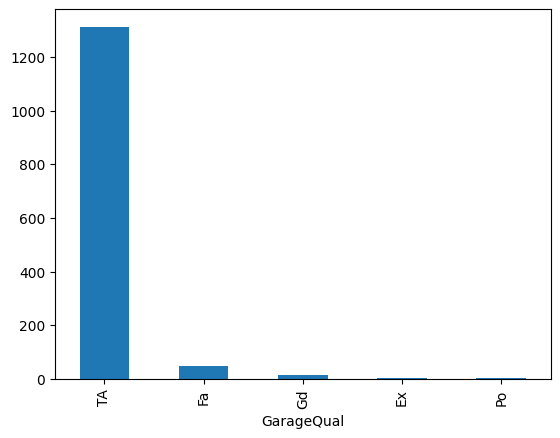

In [6]:
df['GarageQual'].value_counts().plot(kind='bar')

In [8]:
df['GarageQual'].mode()  # finding mode of garagequality

0    TA
Name: GarageQual, dtype: object

Text(0.5, 1.0, 'GarageQual')

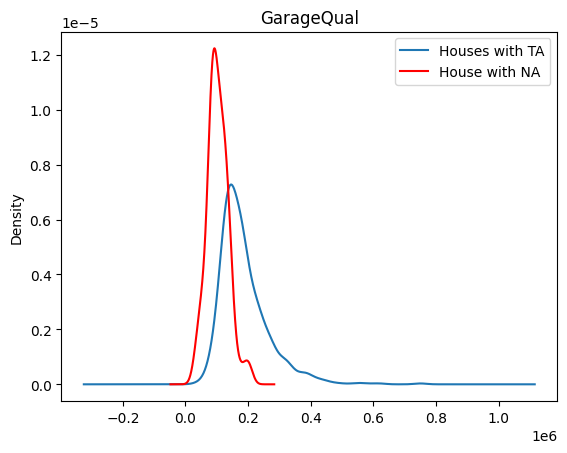

In [10]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde',ax=ax)

df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde' , ax=ax , color='red')

lines , labels = ax.get_legend_handles_labels()
labels = ['Houses with TA' , 'House with NA']
ax.legend(lines , labels , loc='best')

plt.title('GarageQual')

In [11]:
temp = df[df['GarageQual']=='TA']['SalePrice']

In [12]:
df['GarageQual'].fillna('TA' , inplace=True)

C:\Users\sapko\AppData\Local\Temp\ipykernel_20116\2508669795.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GarageQual'].fillna('TA' , inplace=True)


<Axes: xlabel='GarageQual'>

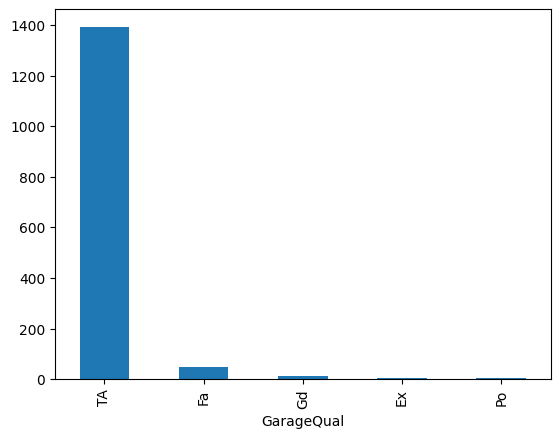

In [13]:
df['GarageQual'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'GarageQual')

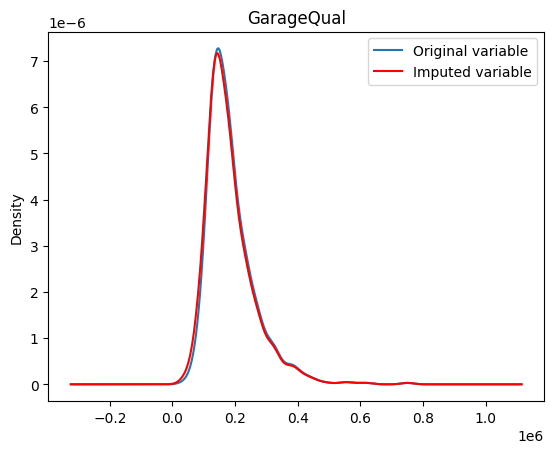

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind='kde' , ax=ax) #blue line

#distribution of the variable after imputation
df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde' , ax=ax , color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Original variable' , 'Imputed variable']
ax.legend(lines , labels , loc='best')

plt.title('GarageQual')

<Axes: xlabel='FireplaceQu'>

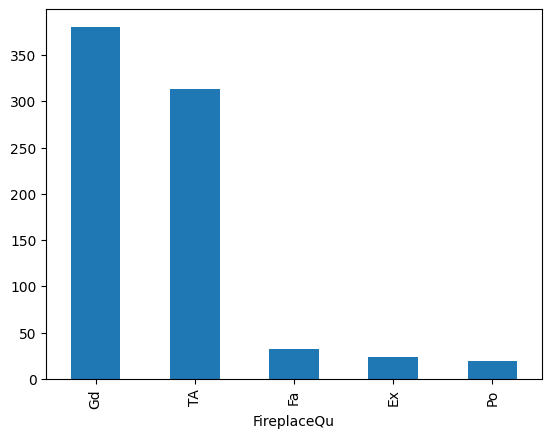

In [17]:
df['FireplaceQu'].value_counts().plot(kind='bar') #here 50per values are missing , and here 2 categories are similar in values, this should not happen

In [18]:
df['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: object

Text(0.5, 1.0, 'FireplaceQu')

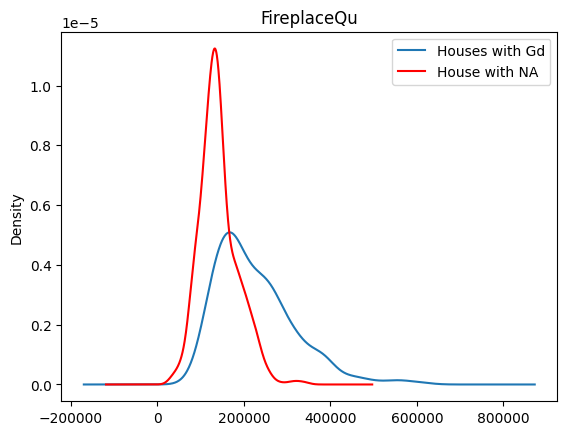

In [19]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde',ax=ax)

df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde' , ax=ax , color='red')

lines , labels = ax.get_legend_handles_labels()
labels = ['Houses with Gd' , 'House with NA']
ax.legend(lines , labels , loc='best')

plt.title('FireplaceQu')

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test , y_train, y_test = train_test_split(df.drop(columns=['SalePrice']),df['SalePrice'],test_size=0.2)

In [21]:
from sklearn.impute import SimpleImputer

In [22]:
imputer = SimpleImputer(strategy='most_frequent')

In [23]:
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_train)

C:\Users\sapko\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


In [24]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)